In [1]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
bids_folder = Path('/data/ds-neuralpriors')
pars_ground_truth = pd.read_csv(bids_folder / 'derivatives' / 'encoding_models' / 'group_roi-NPCr_desc-groundtruth_parameters.tsv', sep='\t', index_col=[0, 1, 2, 3], header=[0, 1, ])
pars_estimates = pd.read_csv(bids_folder / 'derivatives' / 'encoding_models/ 'group_roi-NPCr_desc-responses_parameters.tsv', sep='\t', index_col=[0, 1, 2, 3], header=[0, 1, ])

pars = pd.concat([pars_ground_truth, pars_estimates], keys=['ground_truth', 'estimates'], names=['type'], axis=0)

# rename index level subject_id to subject
pars.index.set_names('subject', level='subject_id', inplace=True)

pars.index.unique(level='smoothed')

Index([True], dtype='bool', name='smoothed')

In [4]:
pars.groupby(['type', 'subject', 'model_label']).size().groupby(['model_label', 'type']).size()

model_label  type        
0            estimates       39
             ground_truth    39
1            estimates       39
             ground_truth    39
2            estimates       39
             ground_truth    39
3            estimates       39
             ground_truth    39
4            estimates       39
             ground_truth    39
5            estimates       39
             ground_truth    39
6            estimates       39
             ground_truth    33
7            estimates       39
             ground_truth    39
8            estimates       39
             ground_truth    39
dtype: int64

Text(0.5, 0.98, 'Proportion of voxels with CVR2 > 0')

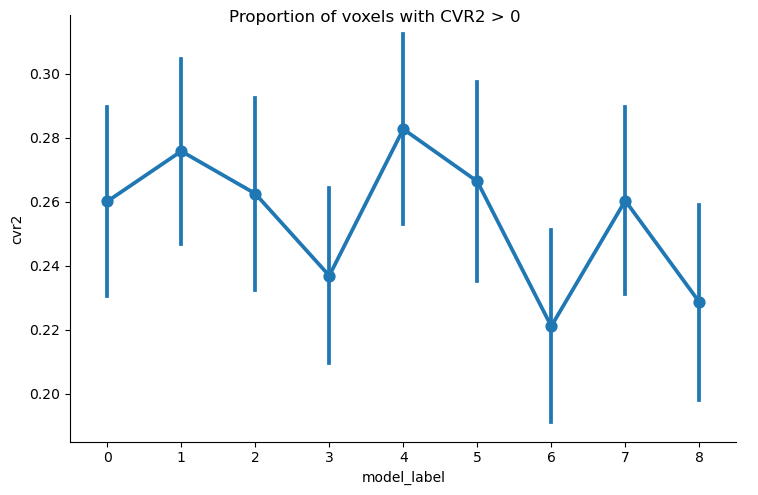

In [5]:
cvr2 = pars[('cvr2', 'nan')].to_frame('cvr2')

cvr2_proportion = cvr2.xs('ground_truth', level='type').groupby(['subject', 'model_label']).apply(lambda x: (x > 0.0).mean())

sns.catplot(x='model_label', y='cvr2', data=cvr2_proportion.reset_index(), kind='point', errorbar='se', aspect=1.5)
plt.suptitle('Proportion of voxels with CVR2 > 0')

Text(0.5, 0.98, 'Proportion of voxels with CVR2 > 0')

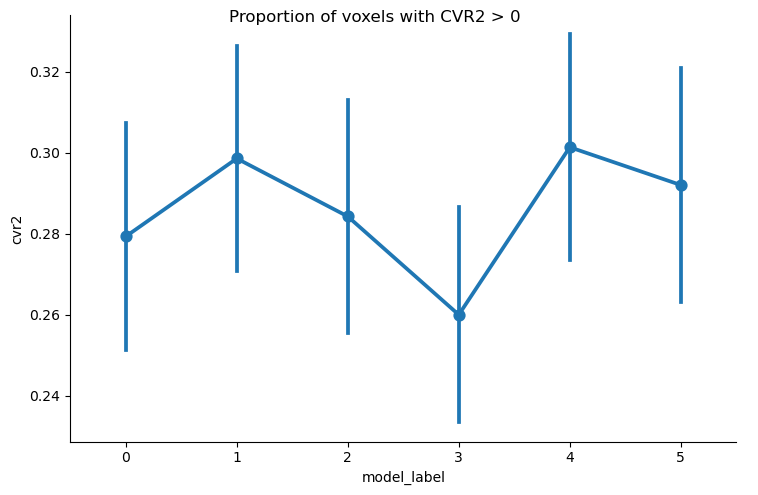

In [26]:
cvr2 = pars[('cvr2', 'nan')].to_frame('cvr2')

cvr2_proportion = cvr2.xs('estimates', level='type').groupby(['subject', 'model_label']).apply(lambda x: (x > 0.0).mean())


# Only select up to model 6
cvr2_proportion = cvr2_proportion[cvr2_proportion.index.get_level_values('model_label') < 6]
cvr2_proportion = cvr2_proportion.reset_index()

sns.catplot(x='model_label', y='cvr2', data=cvr2_proportion.reset_index(), kind='point', errorbar='se', aspect=1.5)
plt.suptitle('Proportion of voxels with CVR2 > 0')

Text(0.5, 0.98, 'Proportion of voxels with CVR2 > 0')

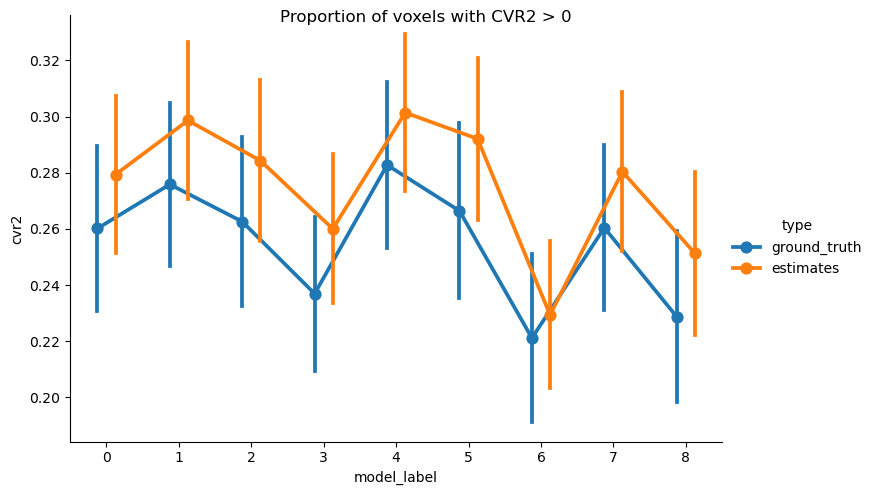

In [27]:
cvr2 = pars[('cvr2', 'nan')].to_frame('cvr2')

cvr2_proportion = cvr2.groupby(['subject', 'model_label', 'type']).apply(lambda x: (x > 0.0).mean())

sns.catplot(x='model_label', y='cvr2', data=cvr2_proportion.reset_index(), kind='point', errorbar='se', hue='type', dodge=.25, aspect=1.5, hue_order=['ground_truth', 'estimates'])
plt.suptitle('Proportion of voxels with CVR2 > 0')

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_26211/416440150.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  g = sns.FacetGrid(pars.xs('ground_truth', level='type', drop_level=False)[pars[('cvr2', 'nan')] > 0.0][('mu')].reset_index(), col='model_label', col_wrap=3)


Text(0.5, 1.05, 'Ground truth narrow vs wide mu')

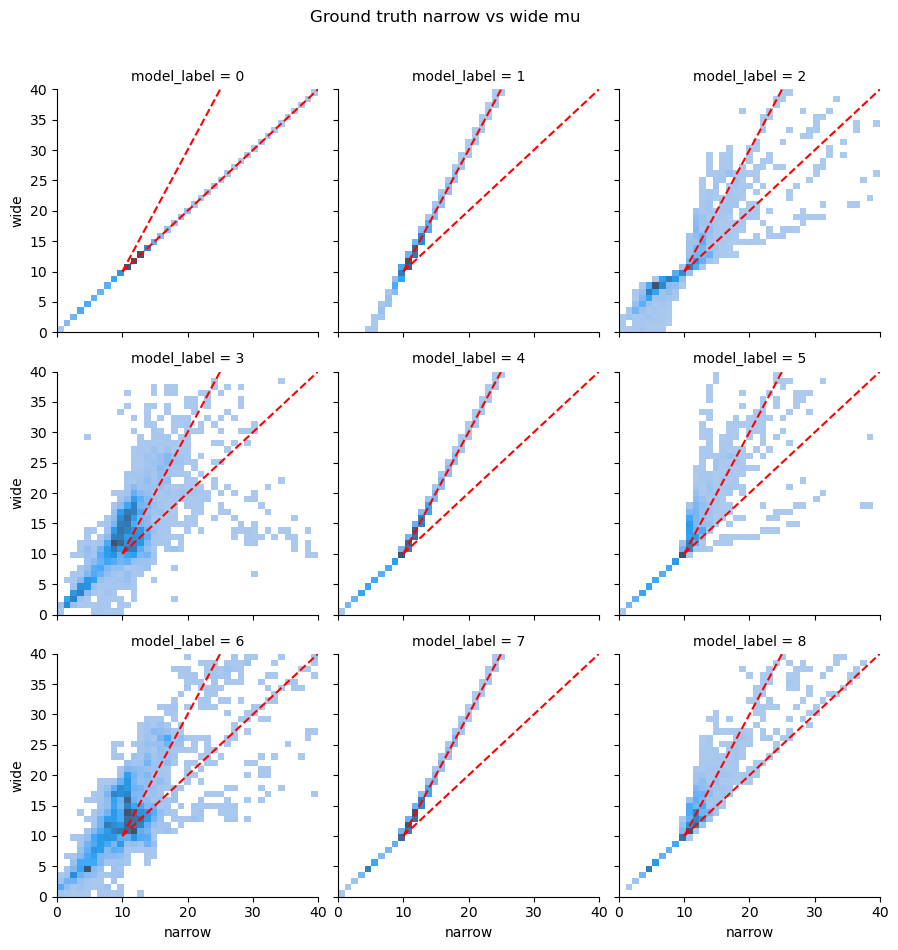

In [8]:
g = sns.FacetGrid(pars.xs('ground_truth', level='type', drop_level=False)[pars[('cvr2', 'nan')] > 0.0][('mu')].reset_index(), col='model_label', col_wrap=3)



g.map(sns.histplot, 'narrow', 'wide', bins=[np.linspace(0, 40, 40), np.linspace(0, 40, 40)])


slope = 1.
g.map(lambda *args, **kwargs: plt.plot([10, 40], [10, 10 + slope*(40-10)], 'r--'))
slope = 2.
g.map(lambda *args, **kwargs: plt.plot([10, 40], [10, 10 + slope*(40-10)], 'r--'))

# g.set_titles('Model {col_name} ({row_name})')

g.set(xlim=(0, 40), ylim=(0, 40))


plt.suptitle('Ground truth narrow vs wide mu', y=1.05)

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_26211/4284264269.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  g = sns.FacetGrid(pars.xs('estimates', level='type', drop_level=False)[pars[('cvr2', 'nan')] > 0.0][('mu')].reset_index(), col='model_label', col_wrap=3)


Text(0.5, 1.05, 'Estimates narrow vs wide mu')

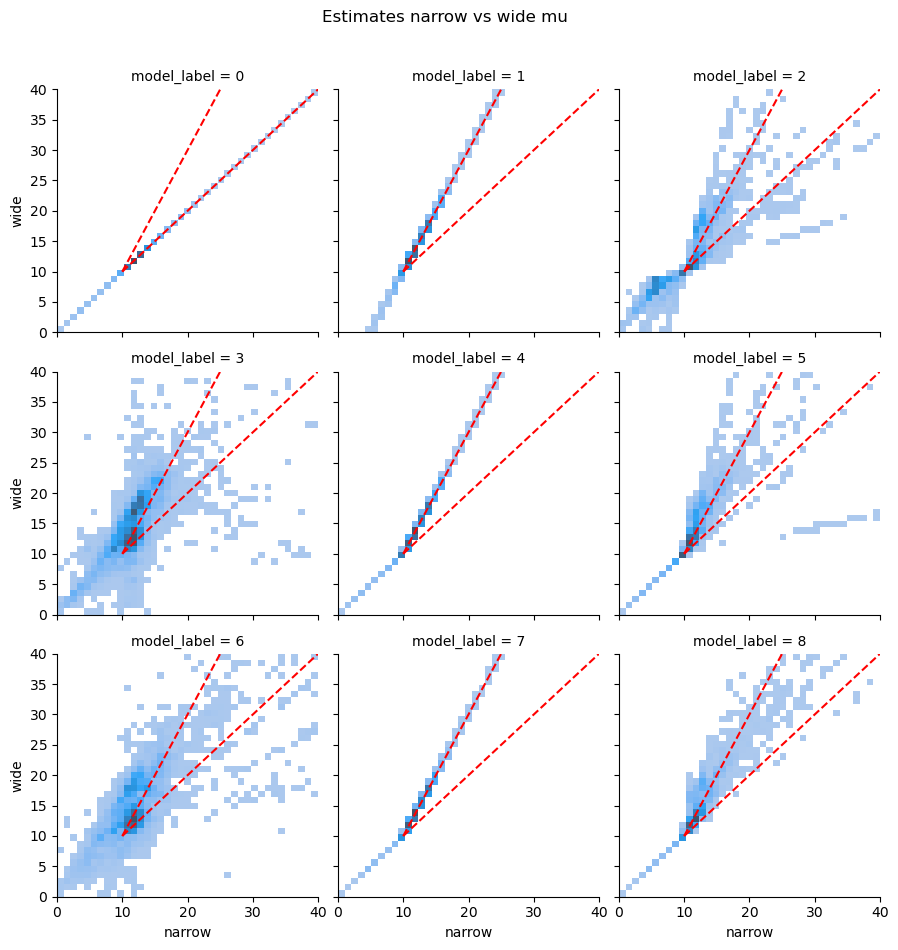

In [9]:
g = sns.FacetGrid(pars.xs('estimates', level='type', drop_level=False)[pars[('cvr2', 'nan')] > 0.0][('mu')].reset_index(), col='model_label', col_wrap=3)



g.map(sns.histplot, 'narrow', 'wide', bins=[np.linspace(0, 40, 40), np.linspace(0, 40, 40)])


slope = 1.
g.map(lambda *args, **kwargs: plt.plot([10, 40], [10, 10 + slope*(40-10)], 'r--'))
slope = 2.
g.map(lambda *args, **kwargs: plt.plot([10, 40], [10, 10 + slope*(40-10)], 'r--'))

# g.set_titles('Model {col_name} ({row_name})')

g.set(xlim=(0, 40), ylim=(0, 40))

plt.suptitle('Estimates narrow vs wide mu', y=1.05)

/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 66.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_26211/45230048.py:19: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(x='model_label', y='delta_wide', data=tmp_reset, hue='type', dodge=0.4,
/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 66.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


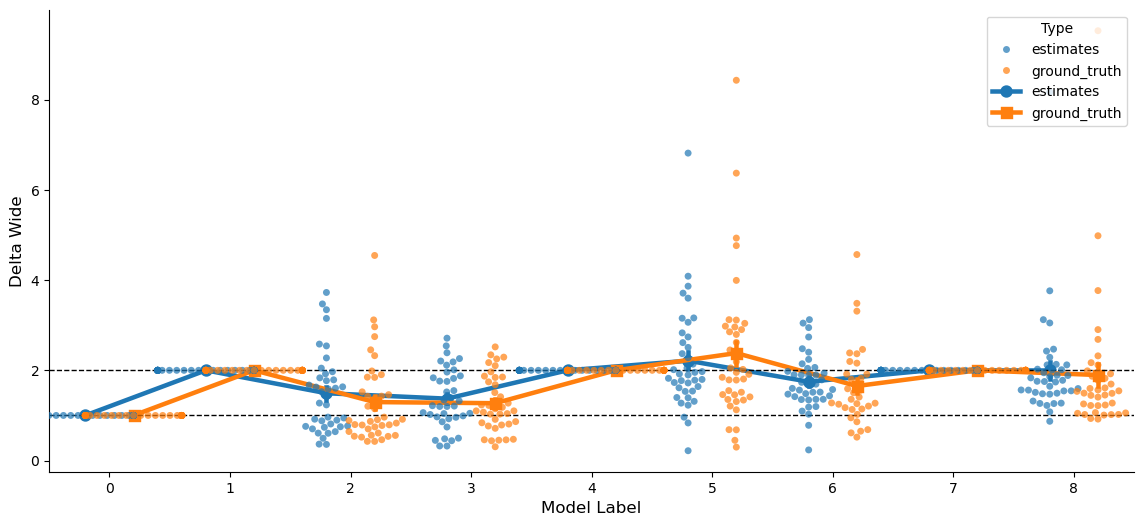

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'tmp' is your DataFrame after grouping and aggregation
tmp = pars[pars[('cvr2', 'nan')] > 0.0]

tmp = tmp.groupby(['subject', 'model_label', 'type'])[[('delta_wide', 'narrow')]].mean().droplevel(1, axis=1)

# Reset index to make 'model_label' and 'type' accessible for plotting
tmp_reset = tmp.reset_index()

# Create the plot with improved readability
plt.figure(figsize=(14, 6))

# Swarm plot with reduced opacity for better visibility
sns.swarmplot(x='model_label', y='delta_wide', data=tmp_reset, hue='type', dodge=True, alpha=0.7)

# Point plot with standard errors and distinct markers
sns.pointplot(x='model_label', y='delta_wide', data=tmp_reset, hue='type', dodge=0.4,
              markers=['o', 's'], scale=1.2, errorbar='se')

# Add horizontal lines
plt.axhline(1.0, c='k', ls='--', linewidth=1)
plt.axhline(2.0, c='k', ls='--', linewidth=1)

# Improve legend and labels
plt.legend(title='Type', loc='upper right')
plt.xlabel('Model Label', fontsize=12)
plt.ylabel('Delta Wide', fontsize=12)
# plt.title('Swarm and Point Plot of Delta Wide by Model Label and Type', fontsize=14)

sns.despine()

# Show the plot
plt.show()


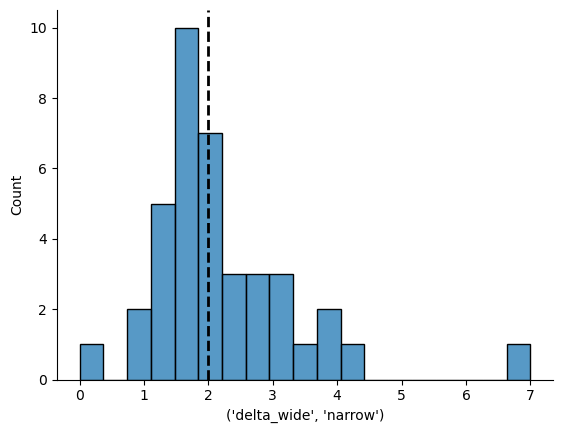

In [11]:
sns.histplot(pars[pars[('cvr2', 'nan')] > 0.0].loc[('estimates', slice(None), 5)][('delta_wide', 'narrow')].groupby(['subject']).mean(),
             bins=np.linspace(0, 7, 20))
plt.axvline(2.0, c='k', ls='--', linewidth=2.)

sns.despine()

/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 85.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 83.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


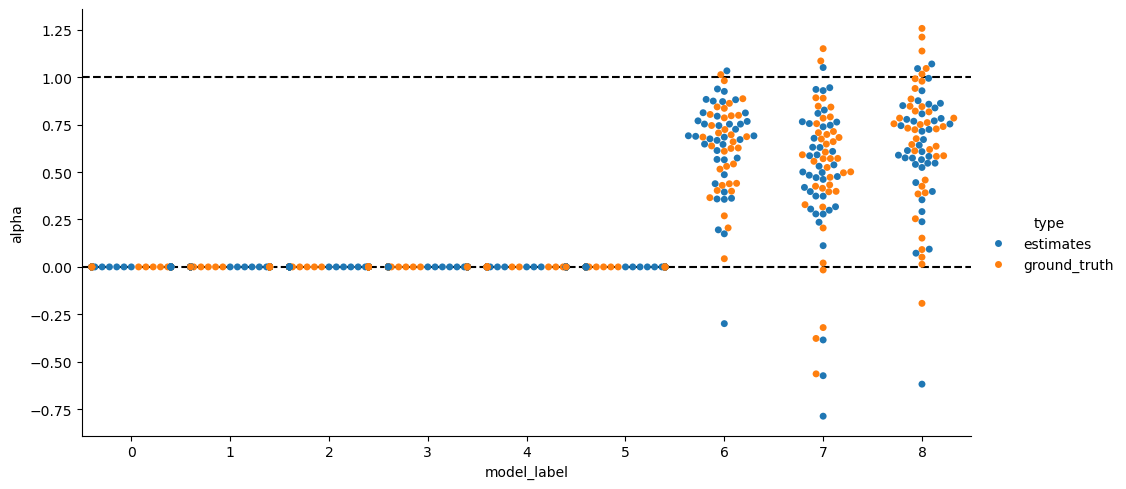

In [12]:
tmp = pars[pars[('cvr2', 'nan')] > 0.0]

tmp = tmp.groupby(['subject', 'model_label', 'type'])[[('alpha', 'narrow')]].mean().droplevel(1, axis=1)

g = sns.catplot(x='model_label', y='alpha', hue='type', data=tmp.reset_index(), kind='swarm', aspect=2.)
plt.axhline(1.0, c='k', ls='--')
plt.axhline(0.0, c='k', ls='--')

/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 66.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_26211/2967506219.py:19: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(x='model_label', y='alpha', data=tmp_reset, hue='type', dodge=0.4,
/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 66.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


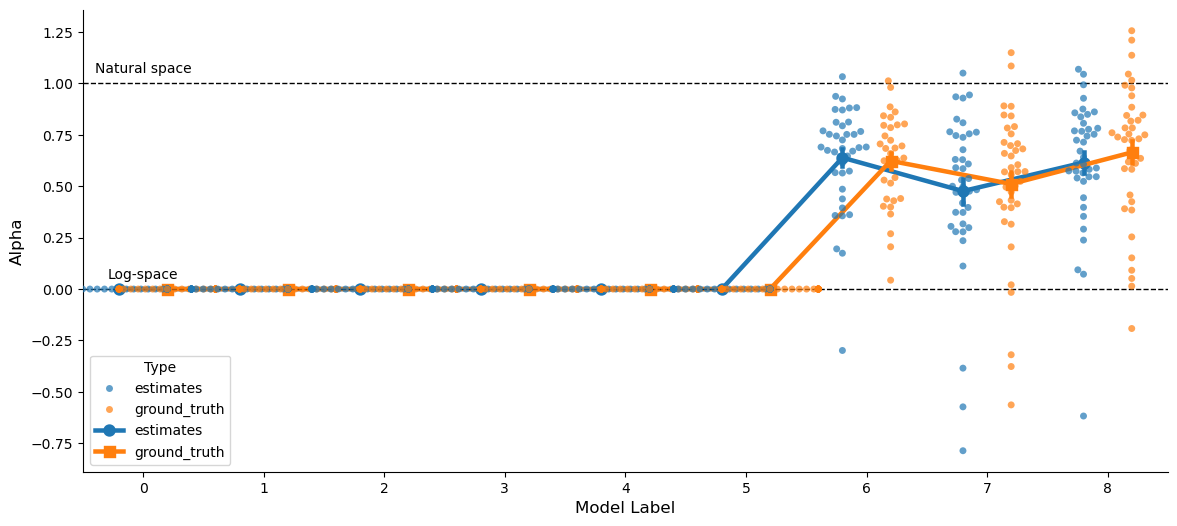

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'tmp' is your DataFrame after grouping and aggregation
tmp = pars[pars[('cvr2', 'nan')] > 0.0]

tmp = tmp.groupby(['subject', 'model_label', 'type'])[[('alpha', 'narrow')]].mean().droplevel(1, axis=1)

# Reset index to make 'model_label' and 'type' accessible for plotting
tmp_reset = tmp.reset_index()

# Create the plot with improved readability
plt.figure(figsize=(14, 6))

# Swarm plot with reduced opacity for better visibility
sns.swarmplot(x='model_label', y='alpha', data=tmp_reset, hue='type', dodge=True, alpha=0.7)

# Point plot with standard errors and distinct markers
sns.pointplot(x='model_label', y='alpha', data=tmp_reset, hue='type', dodge=0.4,
              markers=['o', 's'], scale=1.2, errorbar='se')

# Add horizontal lines
plt.axhline(0.0, c='k', ls='--', linewidth=1)
plt.axhline(1.0, c='k', ls='--', linewidth=1)

plt.annotate('Log-space', xy=(0.0, 0.05), ha='center', fontsize=10)
plt.annotate('Natural space', xy=(0.0, 1.05), ha='center', fontsize=10)

# Improve legend and labels
plt.legend(title='Type')
plt.xlabel('Model Label', fontsize=12)
plt.ylabel('Alpha', fontsize=12)
# plt.title('Swarm and Point Plot of Delta Wide by Model Label and Type', fontsize=14)

sns.despine()

# Show the plot
plt.show()

(440308, 1)


Text(0.5, 1.05, 'Proportion of voxels with CVR2 > 0.0,\nonly voxels where mu_narrow of the null model > 10.')

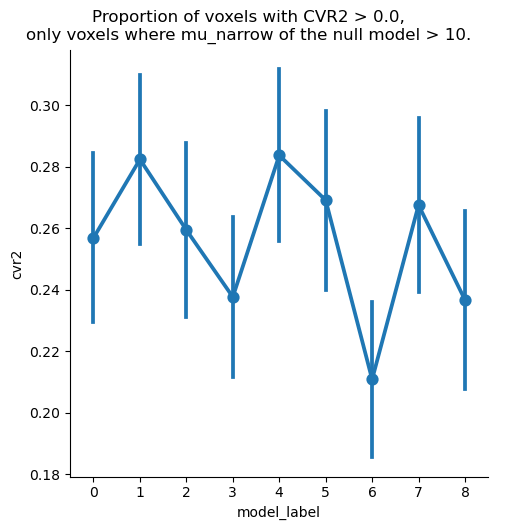

In [14]:
cvr2 = pars[('cvr2', 'nan')].unstack('model_label')
mu = pars[('mu', 'narrow')].unstack('model_label')

cvr2_masked = cvr2[mu[0] > 10.0].stack().to_frame('cvr2')

print(cvr2_masked.shape)


sns.catplot(x='model_label', y='cvr2', data=cvr2_masked.groupby(['subject', 'model_label']).apply(lambda x: (x>0.0).mean()), kind='point', errorbar='se')
plt.suptitle('Proportion of voxels with CVR2 > 0.0,\nonly voxels where mu_narrow of the null model > 10.', y=1.05)

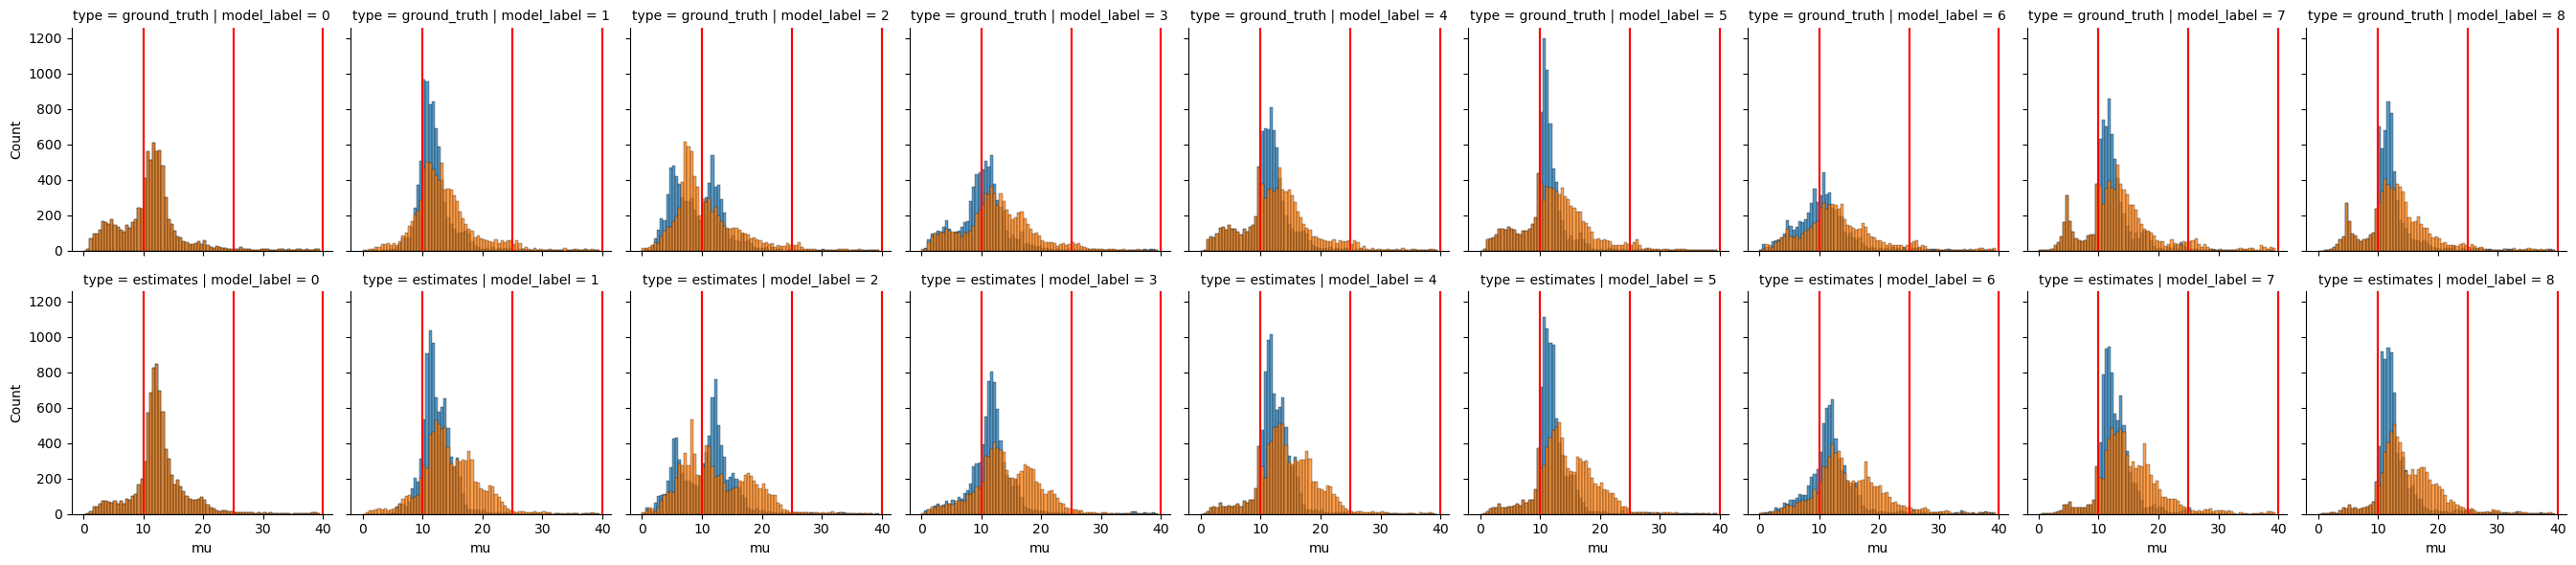

In [15]:
g = sns.FacetGrid(pars[pars[('cvr2', 'nan')] > 0.0]['mu'].stack().to_frame('mu').reset_index(), col ='model_label', row='type', hue='range')
import numpy as np

g.map_dataframe(sns.histplot, 'mu', bins=np.arange(0, 40, .5))

g.map(plt.axvline, x=10.0, color='r')
g.map(plt.axvline, x=25.0, color='r')
g.map(plt.axvline, x=40.0, color='r')

In [28]:
cvr2['larger0'] = cvr2['cvr2'] > 0.0

In [ ]:
pars

parameter                                mu                   sd            \
range                                narrow       wide    narrow      wide   
subject model_label smoothed                                                 
1       0           True     0    10.698851  10.698851  0.128387  0.128387   
                             1    12.097051  12.097051  0.047358  0.047358   
                             2    13.019329  13.019329  0.156827  0.156827   
                             3    15.027272  15.027272  0.071559  0.071559   
                             4    11.410503  11.410503  0.092538  0.092538   
...                                     ...        ...       ...       ...   
41      5           True     689  10.590565  14.978250  0.995034  0.995034   
                             690  10.142032  11.197276  0.049606  0.049606   
                             691  10.652476  15.500143  1.117094  1.117094   
                             692  10.175558  11.479893  0.391492  0.391492   
                             693  10.680551  15.736799  1.253587  1.253587   

parameter                          alpha         delta_wide            \
range                             narrow    wide     narrow      wide   
subject model_label smoothed                                            
1       0           True     0    0.0001  0.0001   1.000000  1.000000   
                             1    0.0001  0.0001   1.000000  1.000000   
                             2    0.0001  0.0001   1.000000  1.000000   
                             3    0.0001  0.0001   1.000000  1.000000   
                             4    0.0001  0.0001   1.000000  1.000000   
...                                  ...     ...        ...       ...   
41      5           True     689  0.0001  0.0001   8.429645  8.429645   
                             690  0.0001  0.0001   8.429645  8.429645   
                             691  0.0001  0.0001   8.429645  8.429645   
                             692  0.0001  0.0001   8.429645  8.429645   
                             693  0.0001  0.0001   8.429645  8.429645   

parameter                        lower_bound_range       amplitude            \
range                                       narrow  wide    narrow      wide   
subject model_label smoothed                                                   
1       0           True     0                10.0  10.0  0.287954  0.287954   
                             1                10.0  10.0  0.396764  0.396764   
                             2                10.0  10.0  0.160411  0.160411   
                             3                10.0  10.0  0.305217  0.305217   
                             4                10.0  10.0  0.359884  0.359884   
...                                            ...   ...       ...       ...   
41      5           True     689              10.0  10.0  0.600452  0.600452   
                             690              10.0  10.0  0.165863  0.165863   
                             691              10.0  10.0  0.805165  0.805165   
                             692              10.0  10.0  0.196186  0.196186   
                             693              10.0  10.0  0.833753  0.833753   

parameter                         baseline                  r2      cvr2  
range                               narrow      wide       nan       nan  
subject model_label smoothed                                              
1       0           True     0   -0.117511 -0.117511  0.007678 -0.018963  
                             1   -0.512096 -0.512096  0.007553 -0.019359  
                             2   -0.514299 -0.514299  0.005133 -0.026070  
                             3   -0.310229 -0.310229  0.014921 -0.021968  
                             4   -0.109330 -0.109330  0.007671 -0.015234  
...                                    ...       ...       ...       ...  
41      5           True     689 -0.184284 -0.184284  0.023590  0.006879  
             

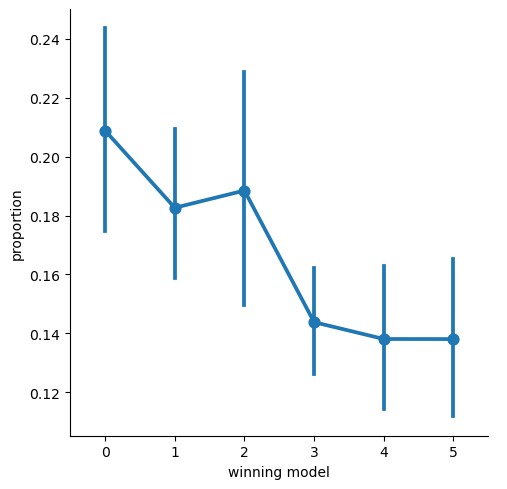

In [ ]:
best_model = cvr2.unstack('model_label').droplevel(0, axis=1).idxmax(axis=1)

best_model_counts = best_model.groupby(['subject']).value_counts(normalize=True).reset_index().rename(columns={'level_1':'winning model'})

sns.catplot(x='winning model', y='proportion', data=best_model_counts, kind='point')

/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 85.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 7.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 83.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 5.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, Use

Text(0.5, 0.98, 'Slope mu_wide ~ mu_narrow')

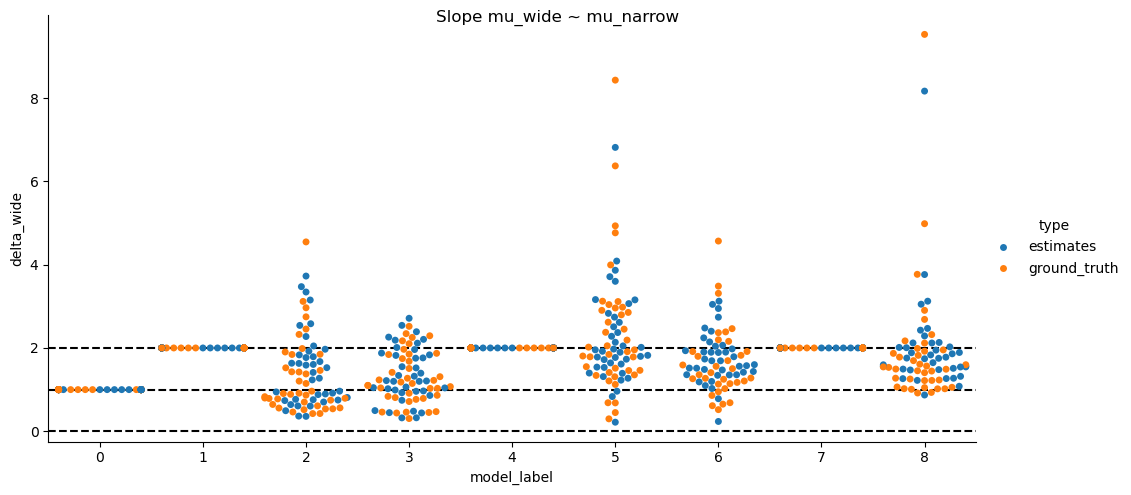

In [ ]:
import pingouin as pg

delta_wide = pars[pars['cvr2', 'nan'] > 0.0][('delta_wide', 'narrow')].groupby(['subject', 'model_label', 'type']).mean().to_frame('delta_wide')

sns.catplot(x='model_label', y='delta_wide', data=delta_wide.reset_index(), kind='swarm', aspect=2, hue='type')
plt.axhline(0.0, c='k', ls='--')
plt.axhline(1.0, c='k', ls='--')
plt.axhline(2.0, c='k', ls='--')
plt.suptitle('Slope mu_wide ~ mu_narrow')

# sns.catplot(x='model_label', y='delta_wide', data=delta_wide.reset_index(), kind='point', aspect=2,)

# plt.axhline(0.0, c='k', ls='--')
# plt.axhline(1.0, c='k', ls='--')
# plt.axhline(2.0, c='k', ls='--')

# delta_wide.groupby(['model_label']).apply(lambda d: pg.ttest(d['delta_wide'], 1.0))


# plt.suptitle('Slope mu_wide ~ mu_narrow')

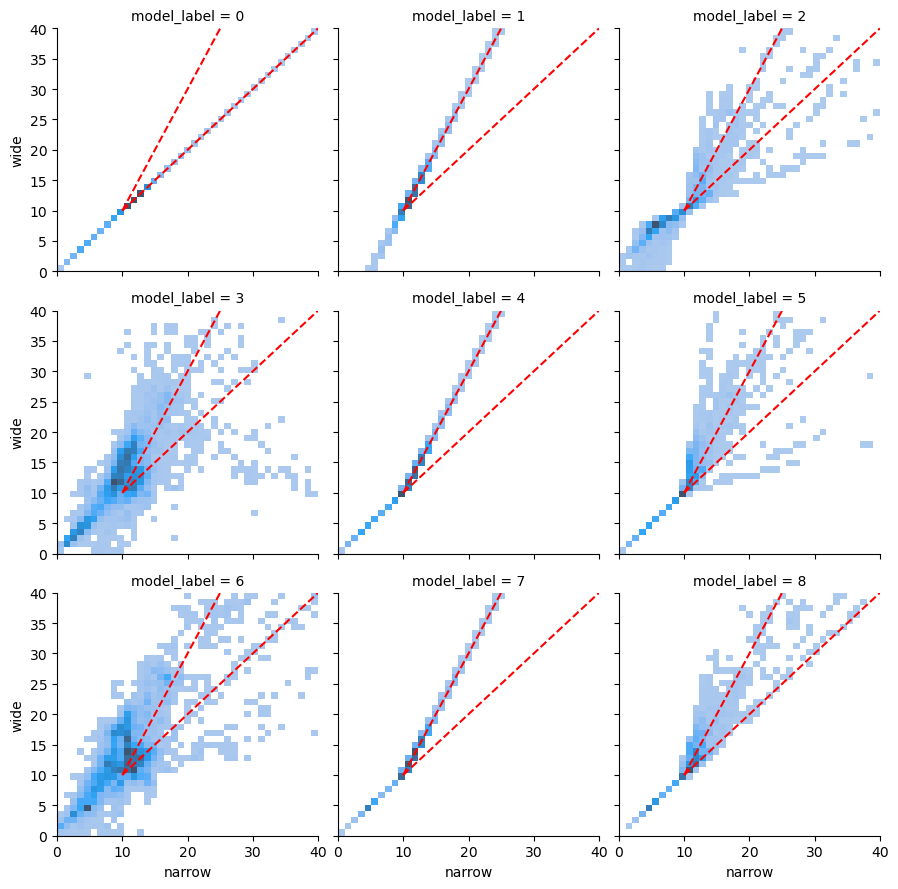

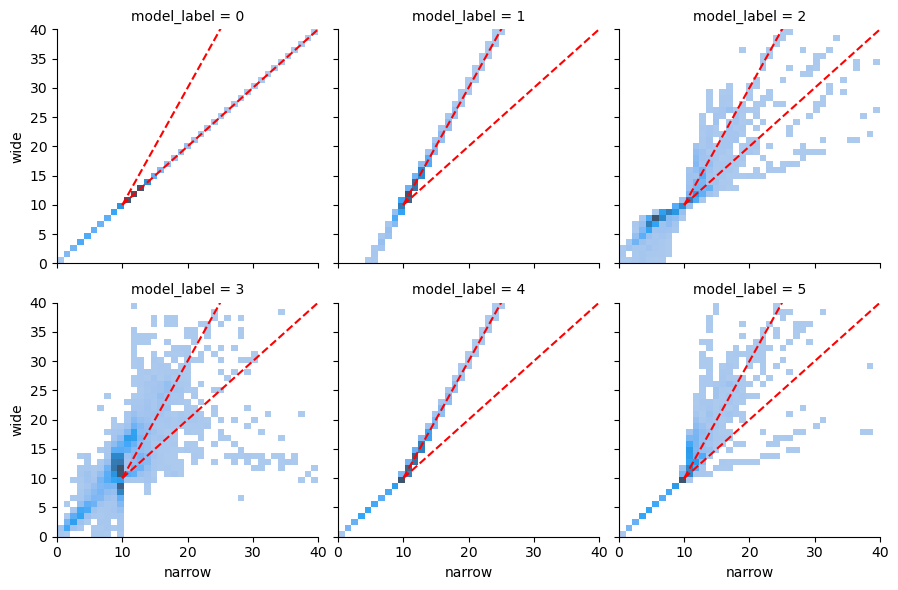

In [ ]:
g = sns.FacetGrid(pars[pars[('cvr2', 'nan')] > 0.0][('mu')].reset_index(), col='model_label', col_wrap=3)



g.map(sns.histplot, 'narrow', 'wide', bins=[np.linspace(0, 40, 40), np.linspace(0, 40, 40)])


slope = 1.
g.map(lambda *args, **kwargs: plt.plot([10, 40], [10, 10 + slope*(40-10)], 'r--'))
slope = 2.
g.map(lambda *args, **kwargs: plt.plot([10, 40], [10, 10 + slope*(40-10)], 'r--'))

# g.set_titles('Model {col_name} ({row_name})')

g.set(xlim=(0, 40), ylim=(0, 40))

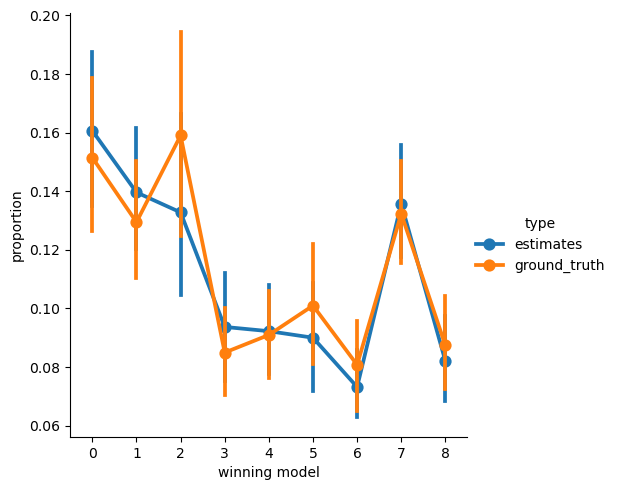

<Figure size 640x480 with 0 Axes>

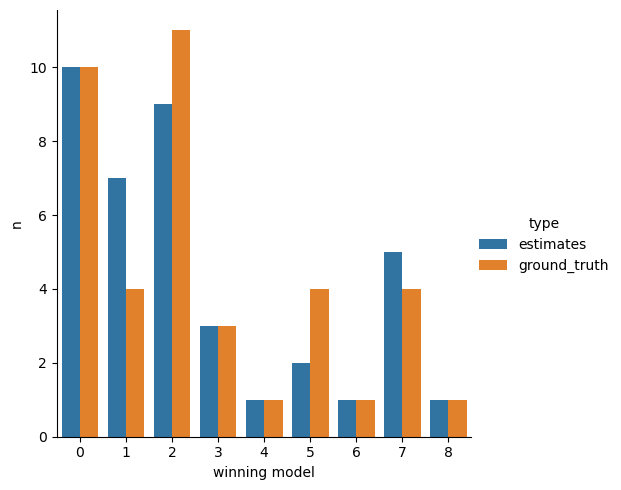

In [ ]:
tmp = cvr2.unstack('model_label').droplevel(0, 1)

winning_model = tmp[(tmp > 0.0).any(axis=1)].idxmax(axis=1)

winning_model_counts = winning_model.groupby(['subject', 'type']).value_counts(normalize=True).reset_index().rename(columns={'level_2':'winning model'})

sns.catplot(x='winning model', y='proportion', hue='type', data=winning_model_counts, kind='point')

plt.figure()

tmp = winning_model.groupby(['subject', 'type']).value_counts(normalize=True)
# sns.catplot(x=tmp.index, y=tmp.values, kind='bar', hue='type')
tmp = tmp.groupby(['type', 'subject']).apply(lambda x: x.idxmax()[-1]).to_frame('winning model')

sns.catplot(x='winning model', y='n', data=tmp.groupby(['type', 'winning model']).size().to_frame('n').reset_index(), hue='type', kind='bar', aspect=1.)


In [ ]:
bids_folder

In [36]:
behavioral_pars = pd.read_csv(bids_folder / 'derivatives' / 'behavioral_modeling' / 'behmodel_3b_pars.csv', index_col=0)

empirical_sd_ratio = pd.read_csv(bids_folder / 'derivatives' / 'behavioral_modeling' / 'subjects_empirical_ratios.csv', index_col=0)

,n,r,CI95%,p-val,power
spearman,39,0.115789,"[-0.21, 0.42]",0.482713,0.108276


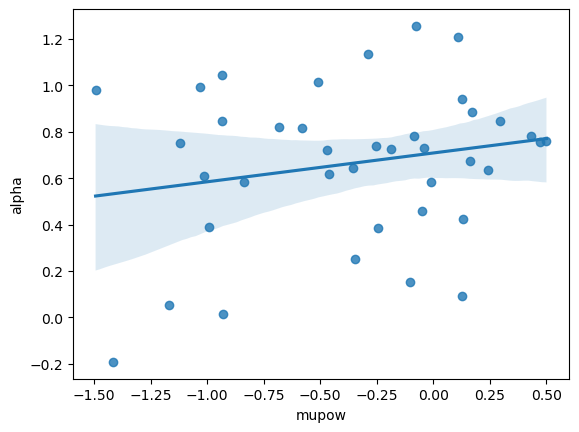

In [37]:
import pingouin as pg
alpha = pars.loc[('ground_truth', slice(None), 8)].groupby(['subject']).mean()[('alpha', 'narrow')].to_frame('alpha')

sns.regplot(x='mupow', y='alpha', data=behavioral_pars.join(alpha))

pg.corr(behavioral_pars['mupow'], alpha['alpha'], method='spearman')

,n,r,CI95%,p-val,power
spearman,39,0.00587,"[-0.31, 0.32]",0.971706,0.049745


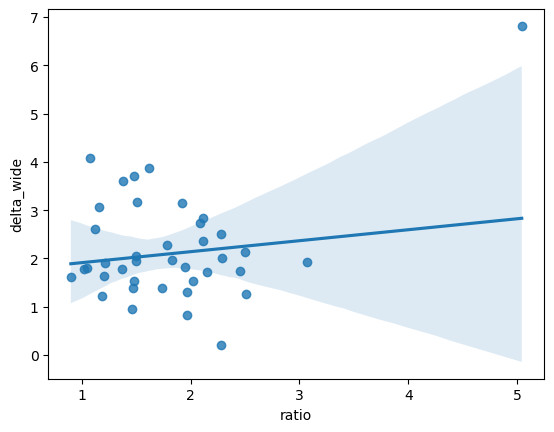

In [41]:
ratio = pars.loc[('estimates', slice(None), 5)].groupby(['subject']).mean()[('delta_wide', 'narrow')].to_frame('delta_wide')

sns.regplot(x='ratio', y='delta_wide', data=behavioral_pars.join(ratio), robust=True)

pg.corr(behavioral_pars['ratio'], ratio['delta_wide'], method='spearman')



<Axes: xlabel='empirical_ratio', ylabel='delta_wide'>

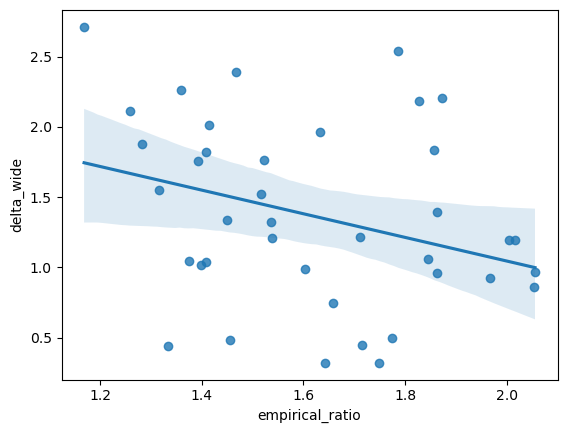

In [52]:
ratio = pars[pars[('cvr2', 'nan')] > 0.0].loc[('estimates', slice(None), 3)].groupby(['subject']).mean()[('delta_wide', 'narrow')].to_frame('delta_wide')
sns.regplot(x='empirical_ratio', y='delta_wide', data=empirical_sd_ratio.join(ratio), robust=True)

,n,r,CI95%,p-val,power
spearman,39,-0.00587,"[-0.32, 0.31]",0.971706,0.049745


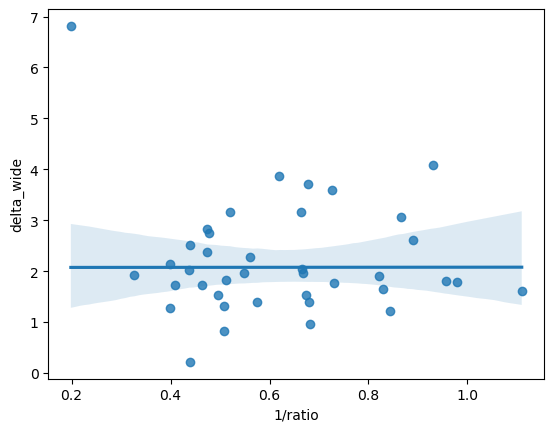

In [29]:
ratio = pars.loc[('estimates', slice(None), 5)].groupby(['subject']).mean()[('delta_wide', 'narrow')].to_frame('delta_wide')

# ratio['1/ratio'] = 1.0 / ratio['ratio']

behavioral_pars['1/ratio'] = 1.0 / behavioral_pars['ratio']

sns.regplot(x='1/ratio', y='delta_wide', data=behavioral_pars.join(ratio), robust=True)

pg.corr(behavioral_pars['1/ratio'], ratio['delta_wide'], method='spearman')

<Axes: xlabel='nu_n', ylabel='Count'>

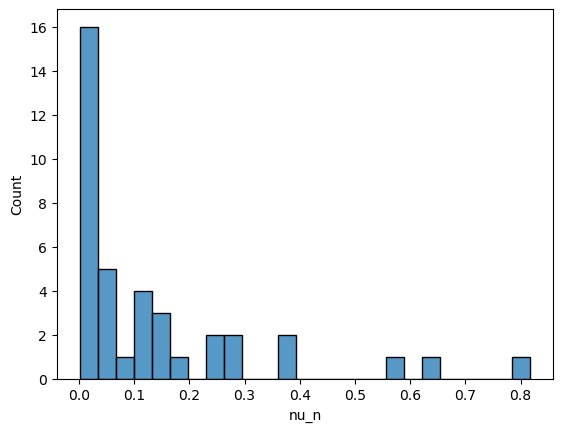

In [30]:
sns.histplot(behavioral_pars['nu_n'], bins=25)

,n,r,CI95%,p-val,power
spearman,39,0.210132,"[-0.11, 0.49]",0.199152,0.25296


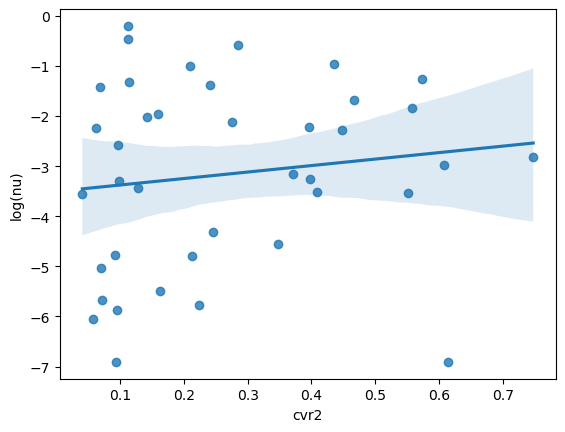

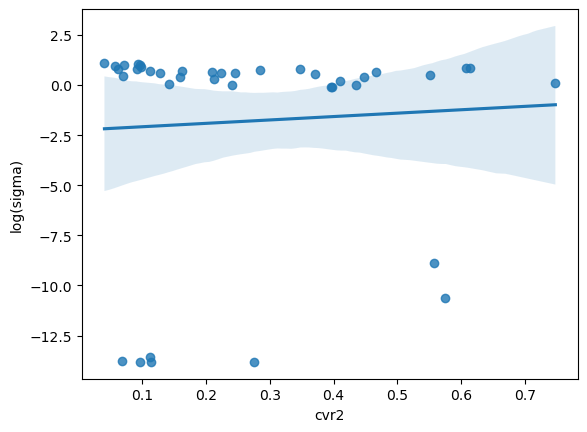

In [33]:
tmp = behavioral_pars.join(cvr2.loc[('ground_truth', slice(None), 5)].groupby(['subject']).apply(lambda x: (x>0.0).mean()))

tmp['log(nu)'] = np.log(tmp['nu_n'])

tmp['log(sigma)'] = np.log(tmp['sigma'])

sns.regplot(x='cvr2', y='log(nu)', data=tmp)

plt.figure()
sns.regplot(x='cvr2', y='log(sigma)', data=tmp)


display(pg.corr(tmp['cvr2'], tmp['nu_n'], method='spearman'))
# display(pg.corr(tmp['cvr2'], tmp['log(sigma)'], method='spearman'))

In [140]:
tmp

,success,mupow,nu_n,ratio,sigma,mll,bic,cvr2,log(nu)
subject,,,,,,,,,
1,True,0.303891,0.457911,1.432555,0.000001,1084.631926,2193.849168,0.112840,-0.781081
2,True,-0.004057,0.234371,0.961924,0.000001,1152.407806,2329.477284,0.111628,-1.450850
3,True,-0.759794,0.012424,2.892315,3.066405,1212.348275,2449.264700,0.040616,-4.388139
4,True,0.399767,0.575856,1.462020,1.544686,1156.344386,2337.282644,0.285161,-0.551898
5,True,-1.399261,0.000785,4.055259,2.634339,1106.280983,2237.223638,0.057607,-7.149194
6,True,-0.923831,0.004735,1.814791,1.773119,1055.081034,2134.832133,0.223602,-5.352779
7,True,0.039894,0.166898,1.148533,0.000036,1078.106262,2180.890967,0.448430,-1.790375
8,True,-0.815256,0.014223,2.004805,2.023076,1148.440836,2321.354061,0.347484,-4.252876
9,True,-0.688732,0.007705,7.647947,1.883605,1165.675889,2356.005037,0.434851,-4.865875


In [97]:
tmp.groupby(['type', 'winning model']).size().to_frame('n').reset_index()

,type,winning model,n
0,estimates,0,10
1,estimates,1,7
2,estimates,2,9
3,estimates,3,3
4,estimates,4,1
5,estimates,5,2
6,estimates,6,1
7,estimates,7,5
8,estimates,8,1
9,ground_truth,0,10


In [78]:
tmp

0    0.256410
1    0.141026
2    0.256410
3    0.076923
4    0.025641
5    0.076923
6    0.025641
7    0.115385
8    0.025641
Name: proportion, dtype: float64

In [75]:
winning_model.groupby(['subject', 'type']).value_counts(normalize=True).reset_index().rename(columns={'level_1':'winning model'})

,subject,type,level_2,proportion
0,1,estimates,0,0.270531
1,1,estimates,8,0.183575
2,1,estimates,7,0.149758
3,1,estimates,6,0.111111
4,1,estimates,1,0.082126
...,...,...,...,...
689,41,ground_truth,8,0.061728
690,41,ground_truth,6,0.059671
691,41,ground_truth,7,0.051440
692,41,ground_truth,4,0.022634


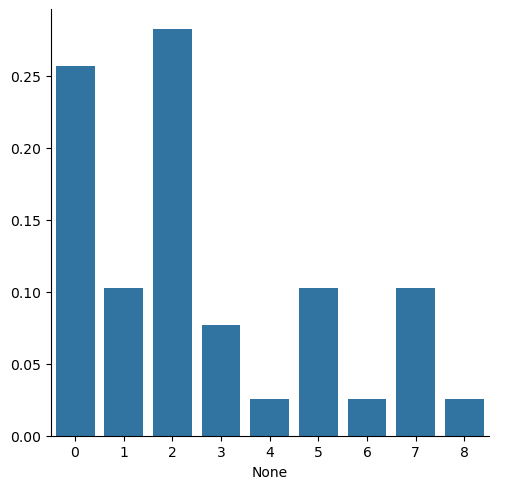

In [149]:
from neural_priors.utils.data import Subject, get_all_subject_ids
import seaborn as sns
import pandas as pd

subjects = get_all_subject_ids()

df = []
for subject in subjects:
    sub = Subject(subject)
    df.append(sub.get_behavioral_data(add_info=True))

df = pd.concat(df)

In [155]:
abs_error = df['abs_error'].groupby(['subject']).mean()

abs_error.index = abs_error.index.astype(int)

In [158]:
behavioral_pars = behavioral_pars.join(abs_error, on='subject')

In [161]:
behavioral_pars['log(nu)'] = np.log(behavioral_pars['nu_n'])

<Axes: xlabel='abs_error', ylabel='log(nu)'>

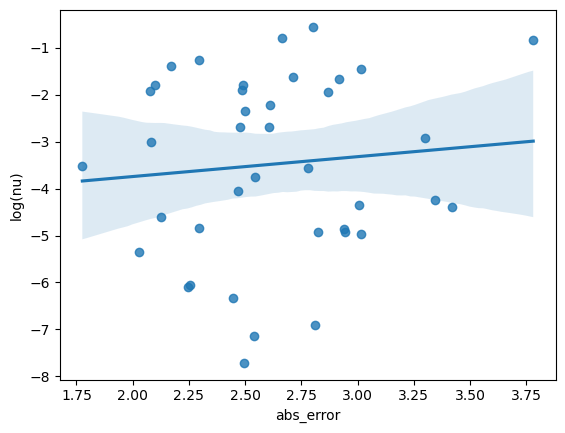

In [162]:
sns.regplot(x='abs_error', y='log(nu)', data=behavioral_pars.join(alpha), robust=True)

,n,r,CI95%,p-val,power
spearman,39,-0.19332,"[-0.48, 0.13]",0.238332,0.22044


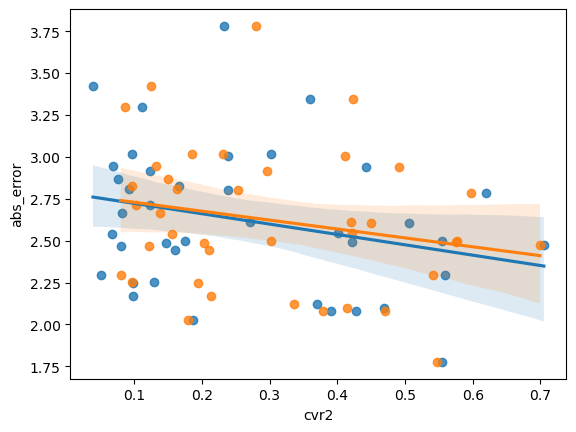

In [186]:

tmp = behavioral_pars.join(cvr2.loc[('ground_truth', slice(None), 2)].groupby(['subject']).apply(lambda x: (x>0.0).mean()))

sns.regplot(x='cvr2', y='abs_error', data=tmp)

pg.corr(tmp['cvr2'], tmp['abs_error'], method='spearman')

tmp = behavioral_pars.join(cvr2.loc[('estimates', slice(None), 4)].groupby(['subject']).apply(lambda x: (x>0.0).mean()))

sns.regplot(x='cvr2', y='abs_error', data=tmp)

pg.corr(tmp['cvr2'], tmp['abs_error'], method='spearman')

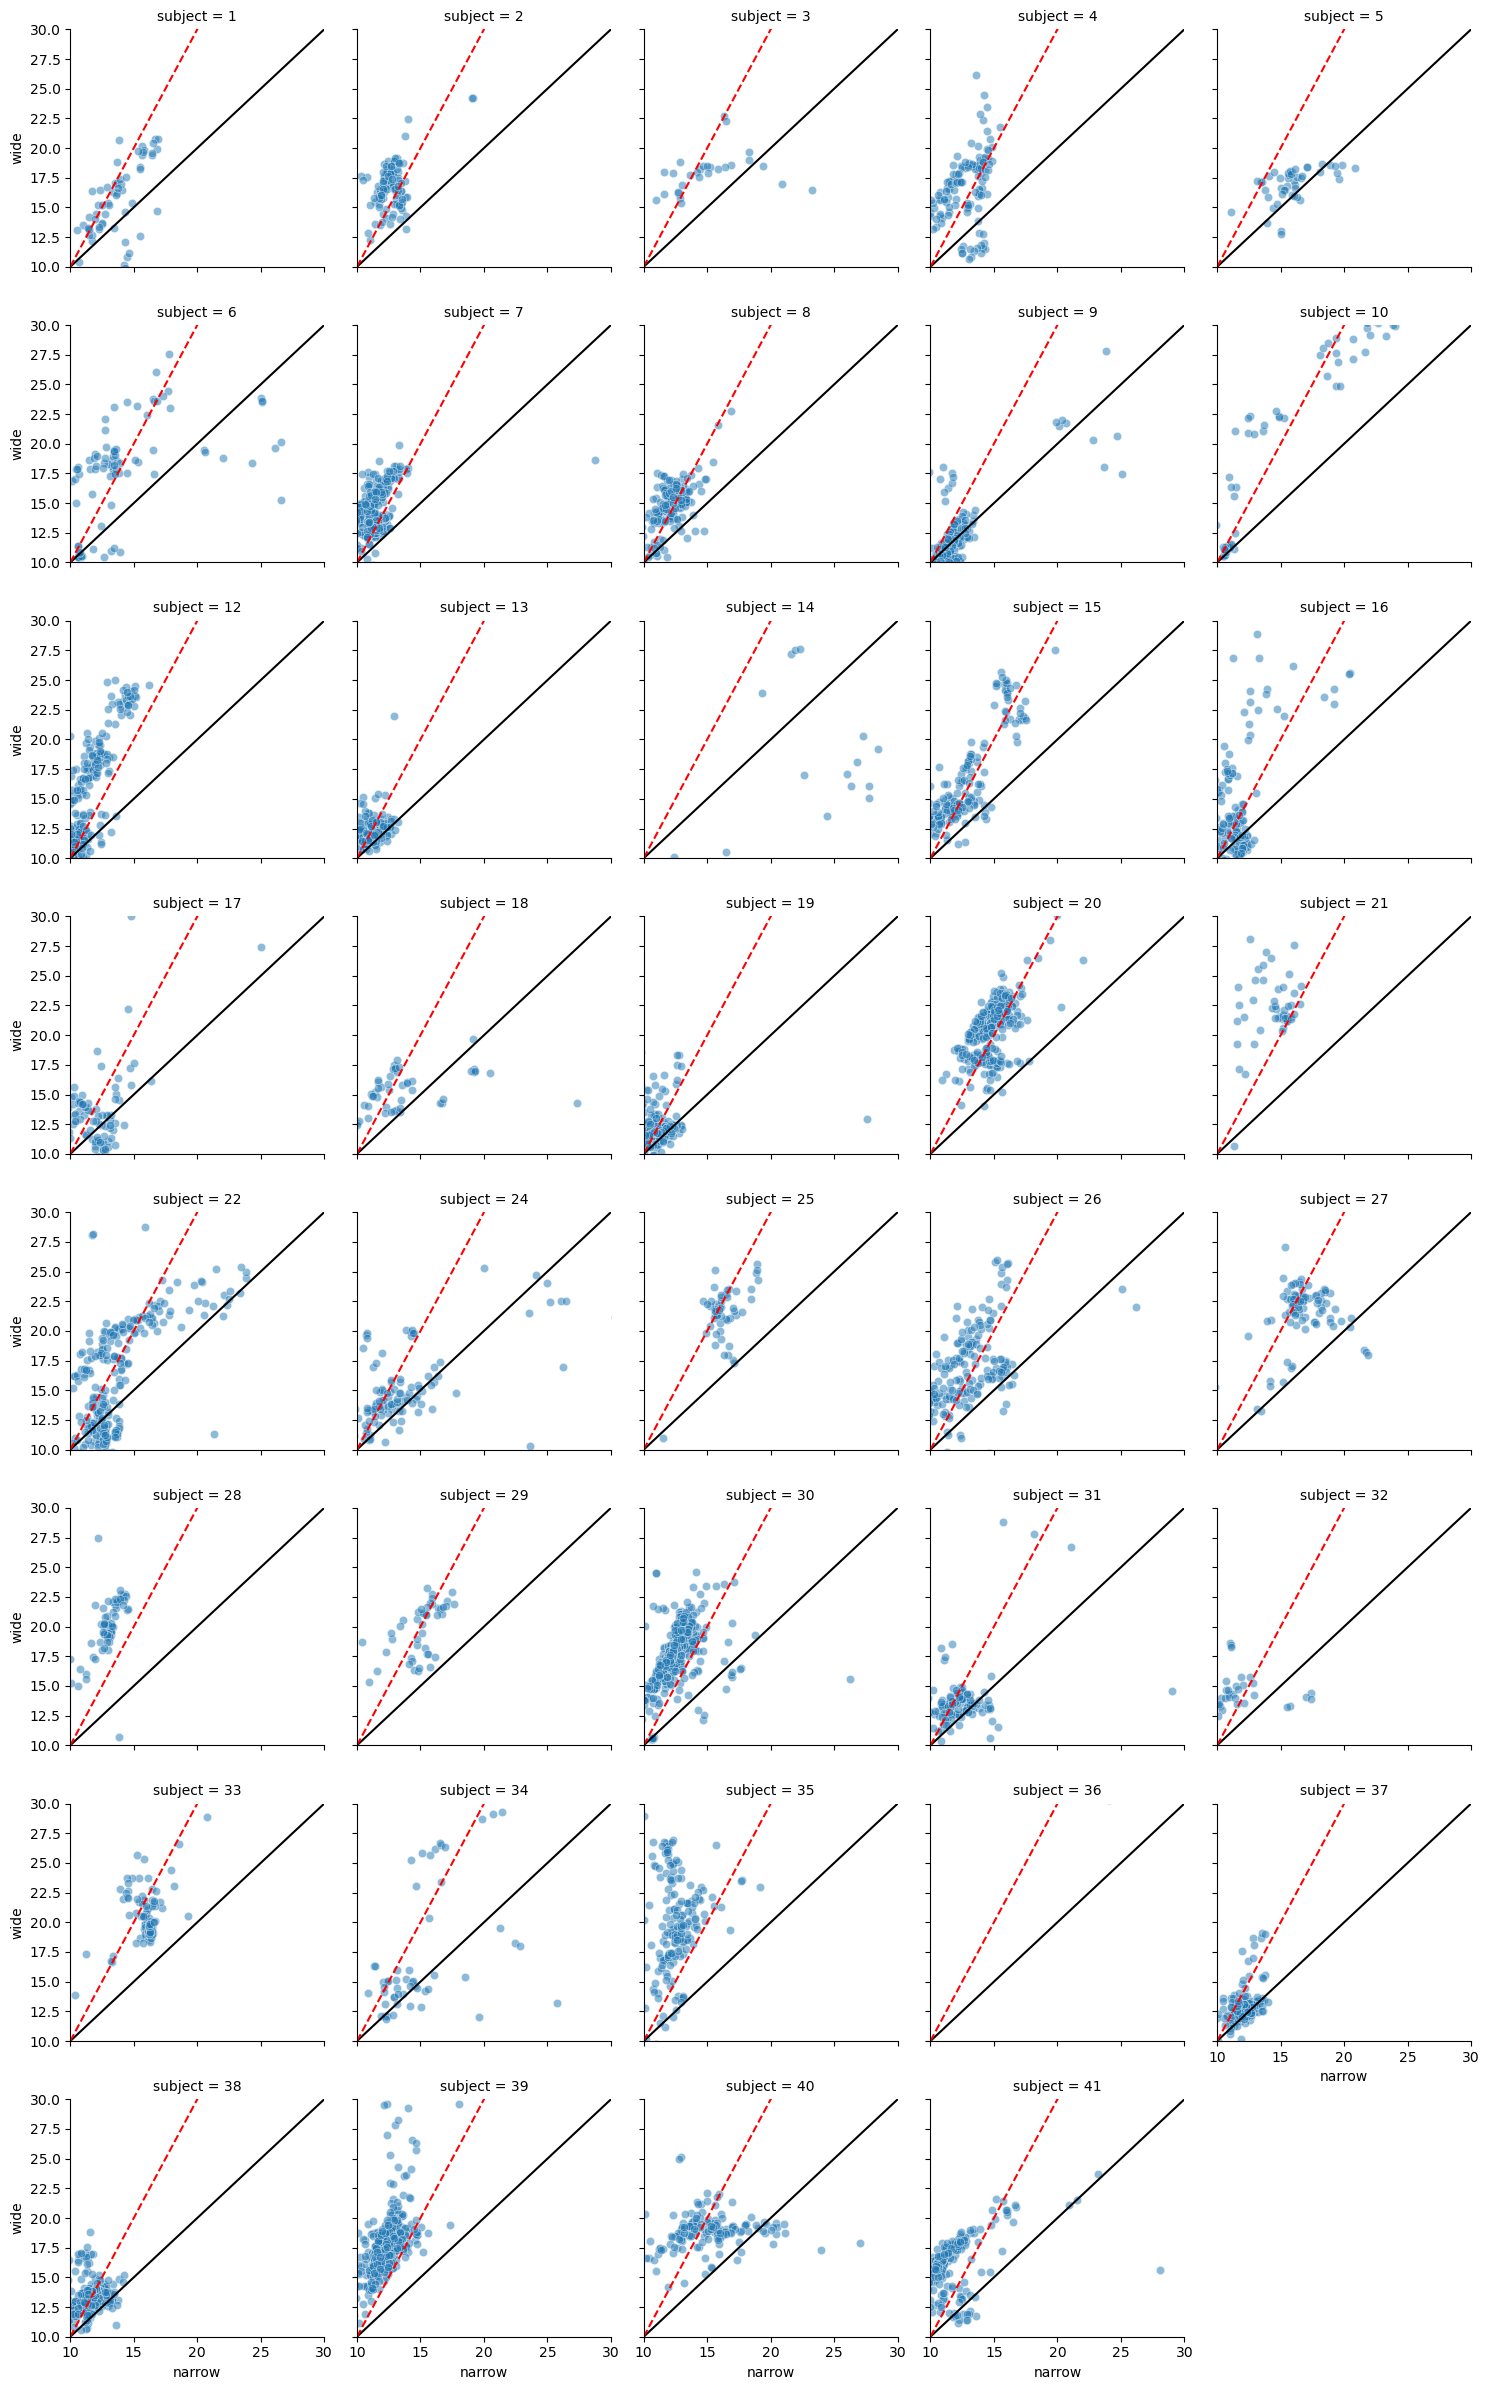

In [234]:
tmp = pars.xs(3, level='model_label').xs('estimates', 0, 'type')
tmp = tmp[tmp[('cvr2', 'nan')] > 0.0]['mu']

g = sns.FacetGrid(tmp.reset_index(), col='subject', col_wrap=5, aspect=1)

# g.map(sns.histplot, 'narrow', 'wide', bins=[np.linspace(0, 40, 40), np.linspace(0, 40, 40)])

g.map(sns.scatterplot, 'narrow', 'wide', alpha=0.5)


g.set(xlim=(10, 30), ylim=(10, 30))

# Map identity line
slope = 1.
g.map(lambda *args, **kwargs: plt.plot([10, 40], [10, 10 + slope*(40-10)], 'k-'))
slope = 2.
g.map(lambda *args, **kwargs: plt.plot([10, 40], [10, 10 + slope*(40-10)], 'r--'))

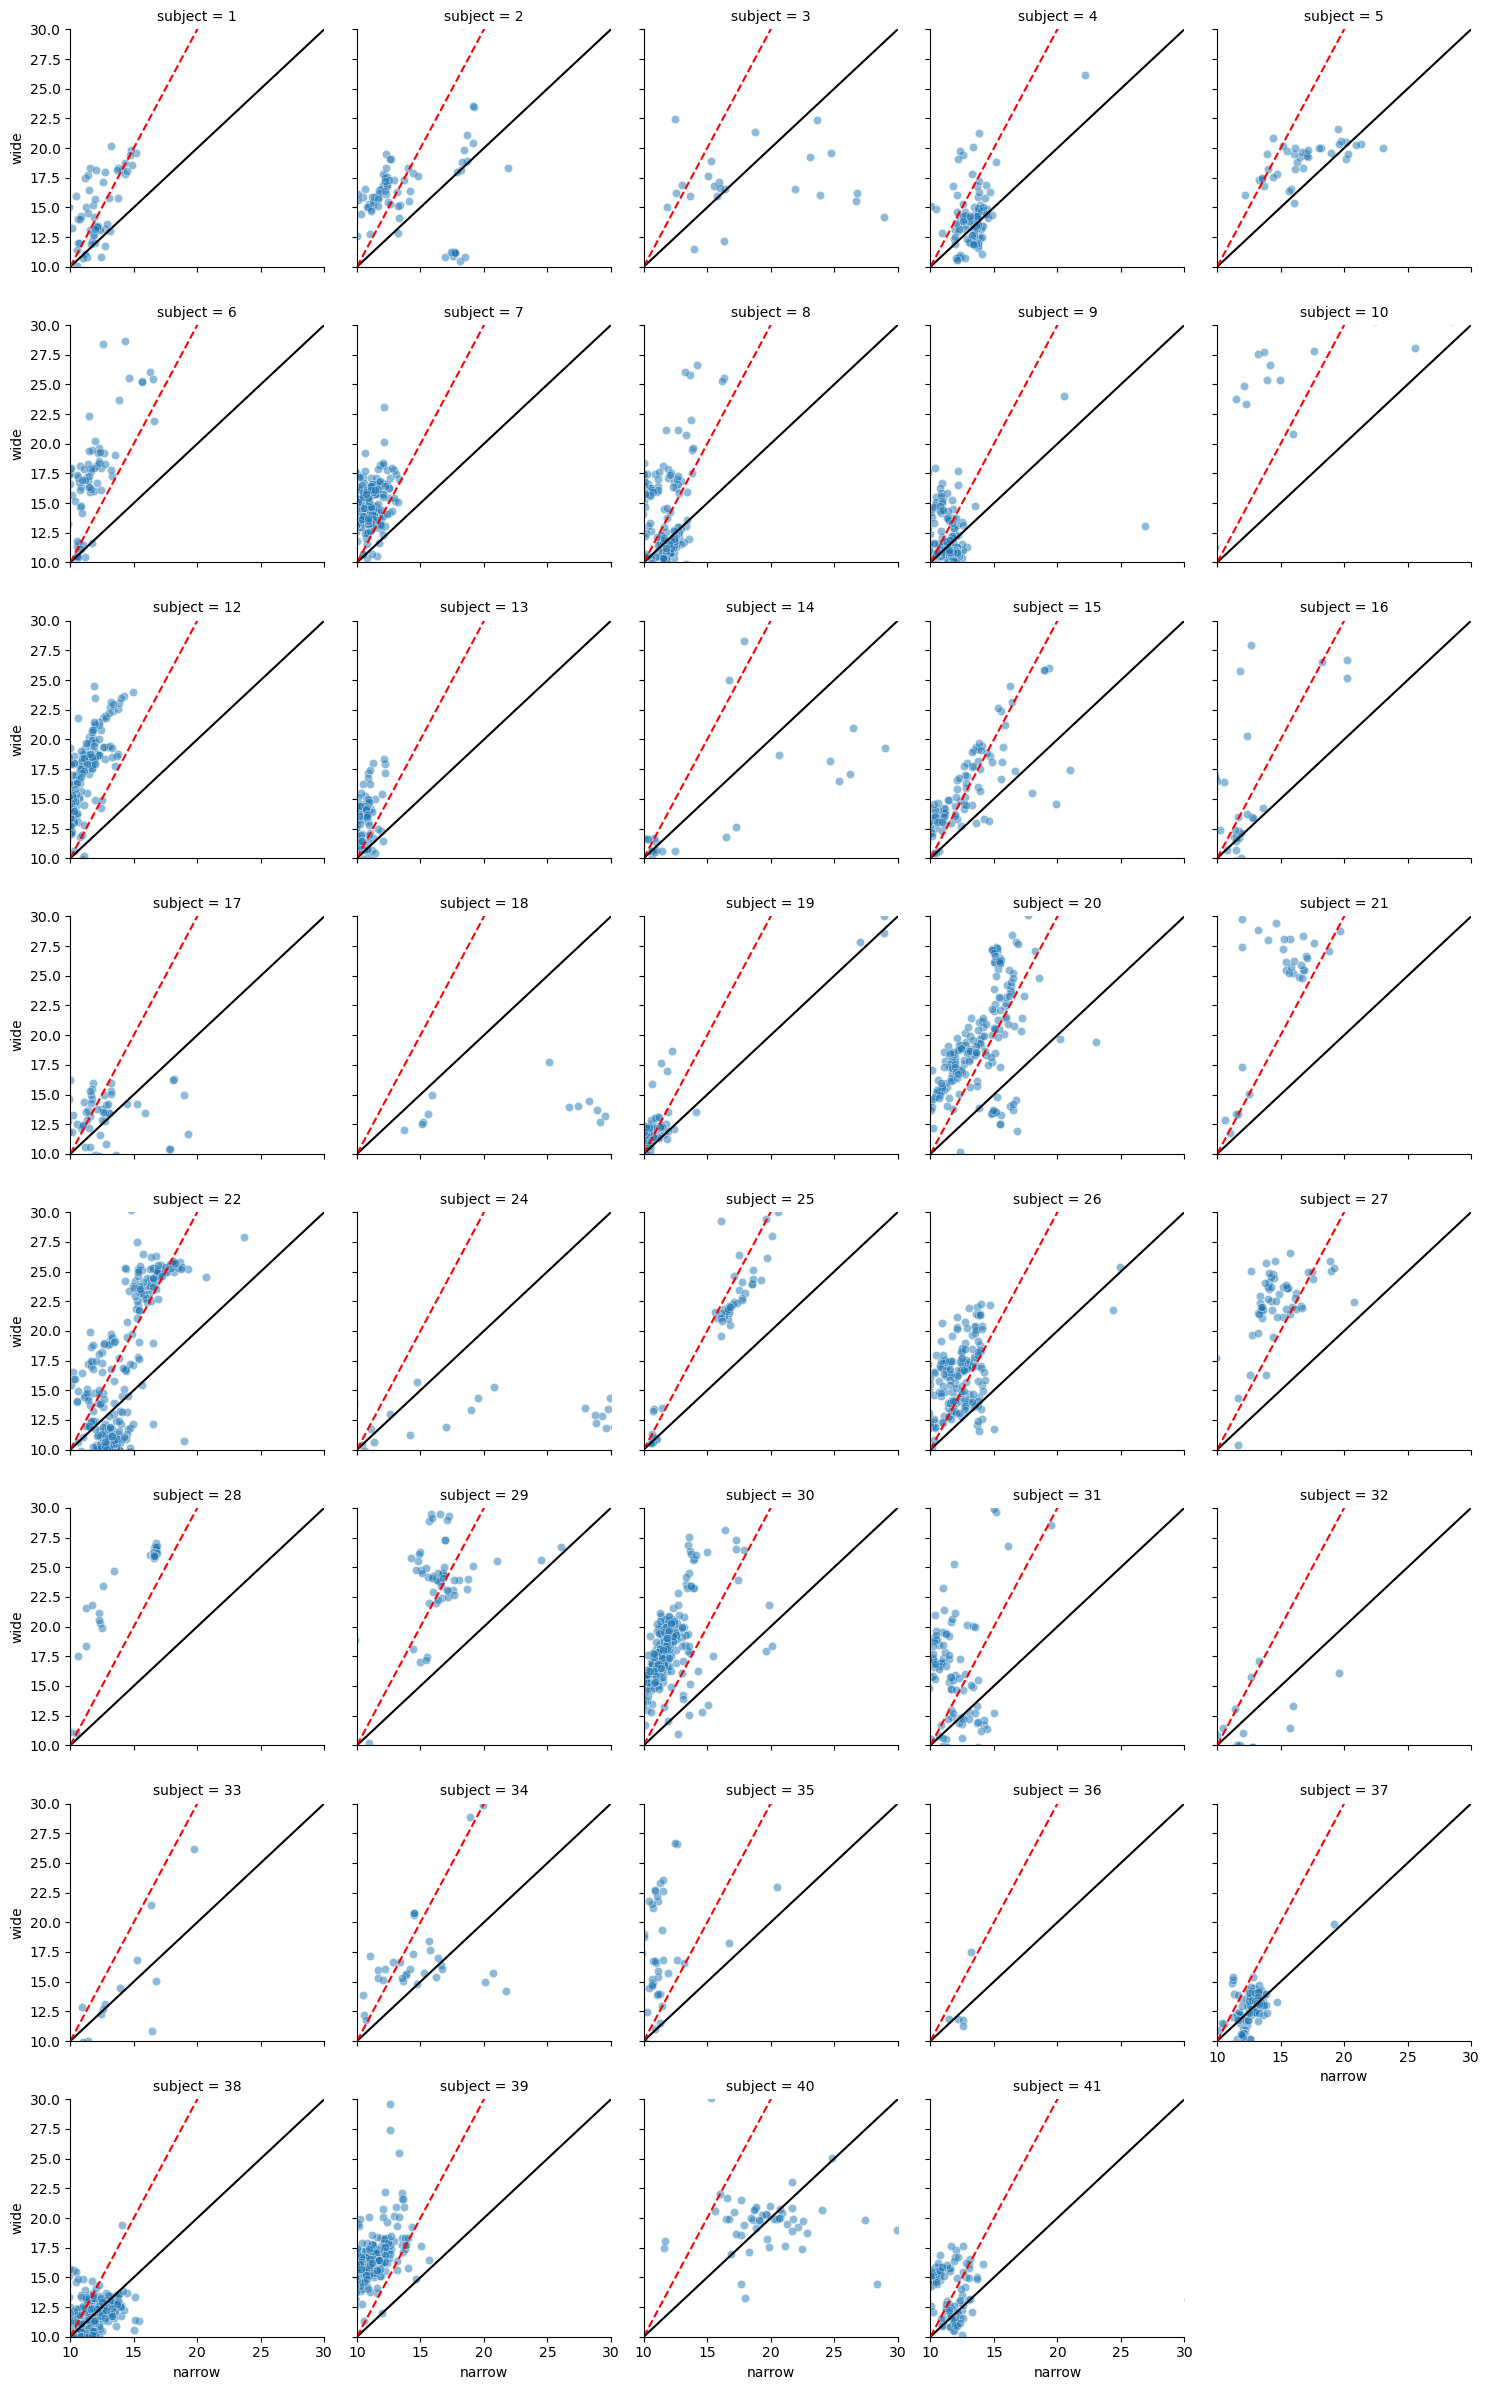

In [233]:
tmp = pars.xs(3, level='model_label').xs('ground_truth', 0, 'type')
tmp = tmp[tmp[('cvr2', 'nan')] > 0.0]['mu']

g = sns.FacetGrid(tmp.reset_index(), col='subject', col_wrap=5, aspect=1)

# g.map(sns.histplot, 'narrow', 'wide', bins=[np.linspace(0, 40, 40), np.linspace(0, 40, 40)])

g.map(sns.scatterplot, 'narrow', 'wide', alpha=0.5)


g.set(xlim=(10, 30), ylim=(10, 30))

# Map identity line
slope = 1.
g.map(lambda *args, **kwargs: plt.plot([10, 40], [10, 10 + slope*(40-10)], 'k-'))
slope = 2.
g.map(lambda *args, **kwargs: plt.plot([10, 40], [10, 10 + slope*(40-10)], 'r--'))

In [238]:
pars

parameter                                             mu              \
range                                             narrow        wide   
type         subject model_label smoothed                              
ground_truth 1       0           True     0    10.698851   10.698851   
                                          1    12.097051   12.097051   
                                          2    13.019329   13.019329   
                                          3    15.027272   15.027272   
                                          4    11.410503   11.410503   
...                                                  ...         ...   
estimates    41      8           True     689  10.876963   17.161741   
                                          690  25.326685  135.165800   
                                          691  10.939777   17.674719   
                                          692  11.833214   24.970993   
                                          693  11.032838   18.434700   

parameter                                            sd               alpha  \
range                                            narrow      wide    narrow   
type         subject model_label smoothed                                     
ground_truth 1       0           True     0    0.128387  0.128387  0.000100   
                                          1    0.047358  0.047358  0.000100   
                                          2    0.156827  0.156827  0.000100   
                                          3    0.071559  0.071559  0.000100   
                                          4    0.092538  0.092538  0.000100   
...                                                 ...       ...       ...   
estimates    41      8           True     689  0.815768  0.815768  0.072412   
                                          690  1.051505  1.051505  0.072412   
                                          691  0.733445  0.733445  0.072412   
                                          692  0.014114  0.014114  0.072412   
                                          693  0.705718  0.705718  0.072412   

parameter                                               delta_wide            \
range                                              wide     narrow      wide   
type         subject model_label smoothed                                      
ground_truth 1       0           True     0    0.000100   1.000000  1.000000   
                                          1    0.000100   1.000000  1.000000   
                                          2    0.000100   1.000000  1.000000   
                                          3    0.000100   1.000000  1.000000   
                                          4    0.000100   1.000000  1.000000   
...                                                 ...        ...       ...   
estimates    41      8           True     689  0.072412   8.166529  8.166529   
                                          690  0.072412   8.166529  8.166529   
                                          691  0.072412   8.166529  8.166529   
                                          692  0.072412   8.166529  8.166529   
                                          693  0.072412   8.166529  8.166529   

parameter                                     lower_bound_range        \
range                                                    narrow  wide   
type         subject model_label smoothed                               
ground_truth 1       0           True     0                10.0  10.0   
                                          1                10.0  10.0   
                                          2                10.0  10.0   
                                          3                10.0  10.0   
                                          4                10.0  10.0   
...                                                         ...   ...   
estimates    41      8           True     689              10.0  10.0   
                                 

In [239]:
pars.groupby(['subject', 'type', 'model_label', 'smoothed']).apply(lambda x: (x['cvr2'] > 0.0).sum())

range                                      nan
subject type         model_label smoothed     
1       estimates    0           True      116
                     1           True       97
                     2           True       78
                     3           True       81
                     4           True      106
...                                        ...
41      ground_truth 4           True      408
                     5           True      426
                     6           True      391
                     7           True      409
                     8           True      412

[696 rows x 1 columns]